# Impulse Response and Transfer Function of Imaging Systems

Aberrations have a strong effect on impulse response of an imaging system. The imaging model shown in Fig 5.1 has a different impulse response depending on the coherence of the object's illumination.
- Spacially Coherent Illumination - Impulse response is called Amplitude Spread Function - Frequency response is called Amplitude Transfer Function
- Spacially Incoherent Illumination - Impulse response is called Point Spread Function  - Frequency response is called Optical Transfer Function

## Coherent Imaging
When incident light is coherent, imaging systems are linear in optical field.

Symbol | Description |
--- | --- |
$U_i(u,v)$ | Image Amplitude |
$U_o(u,v)$ | Object Amplitude |
$h(u,v)$ | Amplitude Spread Function |
$\mathcal{P}(x,y)$ | Generalized Pupil Function |
$z_i$ | Imaging Distance |

Assuming **unit magnification**, the image amplitude is given as:
\begin{equation}
    U_i(u,v) = \int_{-\infty}^\infty \int_{-\infty}^\infty h(u-\eta,v-\xi)U_o(\eta,\xi) d\xi d\eta \\
     = h(u,v)\otimes U_o(u,v)
\end{equation}

For arbitrary, magnification, a scaling of object coordinates is necessary.<br>

The Amplitude Spread Function (impulse response) is given as:

\begin{equation}
    h(u,v) = \frac{1}{\lambda z_i} \int_{-\infty}^\infty \int_{-\infty}^\infty \mathcal{P}(x,y)e^{-i \frac{2\pi}{\lambda z_i}(ux+vy)}dxdy\\
    = \frac{1}{\lambda z_i}\mathcal{F}\{\mathcal{P}(x,y)\}|_{f_x=\frac{u}{\lambda z_i},f_y = \frac{v}{\lambda z_i}}
    \tag{2}
\end{equation}

Generalized Pupil Function $\mathcal{P}(x,y)$ is given as:
\begin{equation}
    \mathcal{P}(x,y) = P(x,y)e^{i2\pi W(x,y)}
\end{equation}

The phase $\phi(x,y)$ can be thought of as:
$$
\phi(x,y) = 2\pi W(x,y)
$$

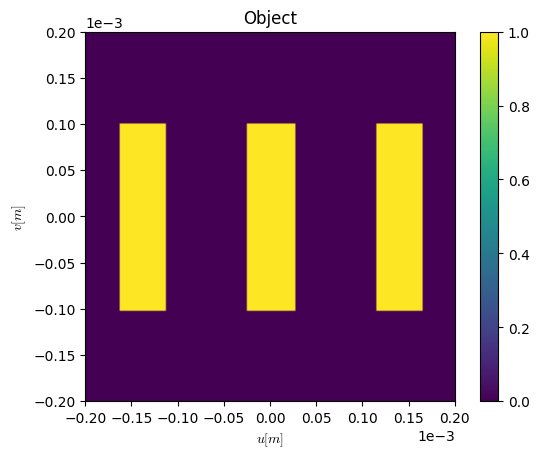

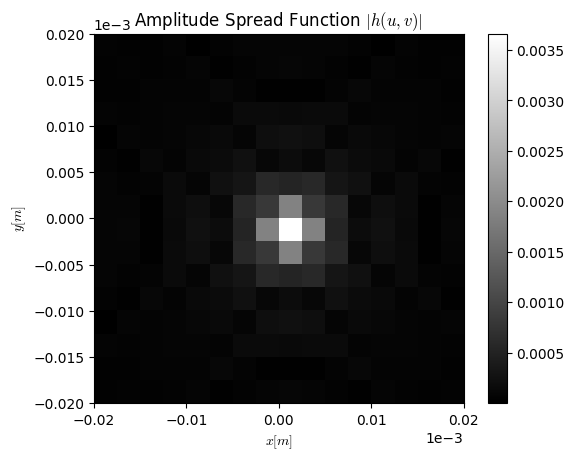

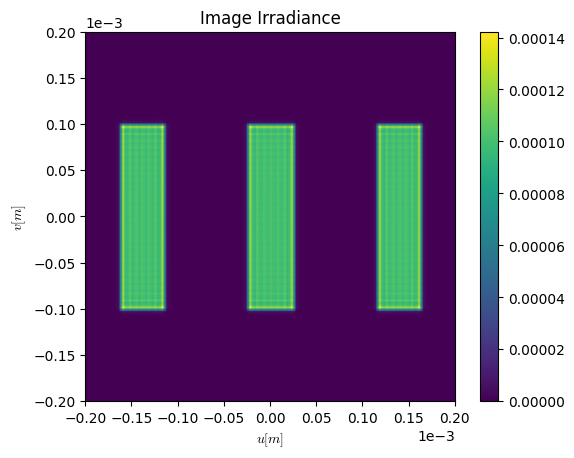

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from optprop.ft_functions import ft2, myconv2
from optprop.aperture_functions import circ, rect
from optprop.zernike import zernike
from optprop.transforms import cart2pol

N = 256
L = 0.1
D = 0.07
delta = L/N
z = 0.25
wvl = 1e-6

x = np.arange(-N/2,N/2,1) * delta
x,y = np.meshgrid(x,x)  # Assuming Square Grid 
r,theta = cart2pol(x,y)
W = 0.05 * zernike(4,2*r/D,theta)
P = circ(x,y,D) * np.exp(1j*2*np.pi*W)
h = ft2(P,delta)
delta_u = (wvl*z)/(N*delta)
u = np.arange(-N/2,N/2,1) * delta_u
u,v = np.meshgrid(u,u)  # Assuming Square Grid
obj = (rect((u-1.4e-4)/5e-5) + rect(u/5e-5) + rect((u+1.4e-4)/5e-5)) * rect(v/2e-4)
img = myconv2(obj,h,1)
Lu = N * delta_u   # Spacial extent of (u,v)

fig,ax = plt.subplots()
im = ax.imshow(obj,extent=[-Lu/2,Lu/2,-Lu/2,Lu/2])
fig.colorbar(im)
ax.set_xlabel(r"$u[m]$",math_fontfamily='cm')
ax.set_ylabel(r"$v[m]$",math_fontfamily='cm')
ax.ticklabel_format(axis='both',style='sci',scilimits=(-3,-3))
ax.set_xlim(-0.2e-3,0.2e-3)
ax.set_ylim(-0.2e-3,0.2e-3)
ax.set_title("Object")

# Amplitude Spread Function Plot
fig,ax = plt.subplots()
im = ax.imshow(np.abs(h),extent=[-Lu/2,Lu/2,-Lu/2,Lu/2],cmap='gray')
fig.colorbar(im)
ax.set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax.set_ylabel(r"$y[m]$",math_fontfamily='cm')
ax.ticklabel_format(axis='both',style='sci',scilimits=(-3,-3))
ax.set_xlim(-0.02e-3,0.02e-3)
ax.set_ylim(-0.02e-3,0.02e-3)
ax.set_title("Amplitude Spread Function $|h(u,v)|$",math_fontfamily='cm')

fig,ax = plt.subplots()
im = ax.imshow(np.abs(img)**2,extent=[-Lu/2,Lu/2,-Lu/2,Lu/2])  # Assuming Square Grid
fig.colorbar(im)
ax.set_xlabel(r"$u[m]$",math_fontfamily='cm')
ax.set_ylabel(r"$v[m]$",math_fontfamily='cm')
ax.ticklabel_format(axis='both',style='sci',scilimits=(-3,-3))
ax.set_xlim(-0.2e-3,0.2e-3) # Set limits
ax.set_ylim(-0.2e-3,0.2e-3)
ax.set_title("Image Irradiance")

plt.show()